In [ ]:
import chromadb
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
import umap
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from collections import defaultdict

import json

In [3]:
import cohere
import csv
import numpy as np
import os
from dotenv import load_dotenv

In [4]:
COHERE_API_KEY=''

In [ ]:
import pandas as pd

# Constants
INPUT_CSV = "/home/robin/Downloads/alchemy_guests.csv"
OUTPUT_CSV = "/home/robin/Downloads/alchemy_guests_cleaned_data.csv"

# Load CSV
df = pd.read_csv(INPUT_CSV)
print(df.columns.tolist())

In [6]:
selected_columns = {
    "name": "Name",
    "email": "Email",
    "what’s something you’ve always wanted to learn but haven’t yet? (we’ll use this to match you with great conversation partners!)": "Learning Interest",
    "what's the last thing you worked on that you're proud of? (we’ll use this to match you with great conversation partners!)": "Past Work",
    "what's something you could talk about forever? (we’ll use this to match you with great conversation partners!)": "Talk Forever",
    "what's your hype song?": "Hype Song"
}
df_cleaned = df[list(selected_columns.keys())].rename(columns=selected_columns)

df_cleaned = df_cleaned.drop_duplicates(subset=["Name"], keep="first")

df_cleaned = df_cleaned.replace(["NULL", "null", "None", "none"], "").fillna("")

non_matching_columns = ["Learning Interest", "Past Work", "Talk Forever", "Hype Song"]
df_cleaned = df_cleaned[~(df_cleaned[non_matching_columns] == "").all(axis=1)]

# save cleaned CSV
df_cleaned.to_csv(OUTPUT_CSV, index=False)

In [7]:
# to generate embeddings, 1) initialize cohere client (and chroma), 2) read answers from csv,
# 3) compute cosine similarity for each individual answer

load_dotenv()
#COHERE_API_KEY= os.getenv("COHERE_API_KEY")
co = cohere.Client(COHERE_API_KEY)

In [8]:
CSV_FILE = "/home/robin/Downloads/alchemy_guests_cleaned_data.csv"
# reading csv
attendees = {}
questions = []
with open(CSV_FILE, newline='') as attendees_csv:
    data = csv.reader(attendees_csv, delimiter=',', quotechar='"')
    header = next(data)  
    questions = header[1:] 
    
    for row in data:
        name = row[0]  # name
        print(name)
        answers = row[1:]  # question responses
        attendees[name] = answers  # storing by name

#print(attendees)
#print(questions)

Ahmed Sinjab
Atnasia Ibsa
Akshin Makkar 
Alex Wang
Andy Liu
Ali
Andrew Leest
Arianna Tan
Arthur Huang
Avan
Leon Zhu
Brenda Li
Brooke Lai
Chu Yi Yu
Daniel Wang
Laurel Dong
Ella Schlaghecke
Emily ✿
Gabi Foss
Godwin Chan
Derrick Ha
Hardeep Gambhir
kai
Iris Gu
James Kim
Jasmine
Josh Zucker
Leo Li
Lillian Wei
Lily Yang
Maya Lekhi
Anh
Nirav Patel
Om Gandhi
Pratham
abhi ravipati
Robin Hylands
Ryan Vijan
Sophie Lin
Sachi Sisodia
Trinity Chung
Vincent Xue
Xavier Marc Desroches Desroches Borelly
Yogya Kalra
{'Ahmed Sinjab': ['ahmed.sinjabas@gmail.com', 'Learning how to make a project using a database', 'The last thing that I worked on that I am proud of is an implantation of a binary search tree ', '', 'My own way'], 'Atnasia Ibsa': ['aibsa@uwo.ca', 'how to play the piano ', 'a creativity manifesto (for my creativity course:)', '', ''], 'Akshin Makkar ': ['akshinmakkar8@gmail.com', 'how to juggle ', 'real time sms crime update software from the Toronto police crime database', 'startups', 'headli

In [11]:
# Dictionary to store embeddings, emails, and answers clearly
person_embeddings = {} 

for name, answers in attendees.items():
    # Extract email (assumed always first answer)
    email = answers[0]

    # Exclude email (first column) and get only question answers
    question_answers = answers[1:]
    question_texts = questions[1:]

    # Filter out unanswered or null answers
    valid_answers = [a for a in question_answers if a.strip() and a.strip().upper() != "NULL"]
    valid_questions = [q for q, a in zip(question_texts, question_answers) if a.strip() and a.strip().upper() != "NULL"]

    if not valid_answers:
        continue  # Skip if no valid answers to questions

    # Generate embeddings for valid answers only (excluding emails)
    response = co.embed(
        texts=valid_answers,
        model="embed-english-light-v3.0",
        input_type="search_document"
    )

    embeddings = response.embeddings  # one per question-answer pair

    # Store embeddings with email clearly separated
    person_embeddings[name] = {
        "email": answers[0],
        "embeddings": {q: list(map(float, emb)) for q, emb in zip(valid_questions, embeddings)}
    }

# Save embeddings to JSON file
with open("embeddings.json", "w") as f:
    json.dump(person_embeddings, f, indent=4)

print("✅ Embeddings generated and stored (excluding emails from embeddings, but preserving email addresses).")



✅ Embeddings generated and stored (excluding emails from embeddings, but preserving email addresses).


In [318]:
# Load embeddings from JSON
with open("embeddings.json", "r") as f:
    person_embeddings = json.load(f)

In [ ]:
attendee_names = list(person_embeddings.keys())
num_attendees = len(attendee_names)

# Define category mappings
categories = {
    "learn": "Learning Interest",
    "forever": "Talk Forever",
    "work": "Past Work"
}

CSV_OUTPUT_FILE = "attendee_clusters.csv"

### ======= HYPERPARAMETERS ======= ###
NUM_CLUSTERS = 2     # Number of clusters for Spectral Clustering
PCA_COMPONENTS = 40     # Number of dimensions after PCA
K_NEIGHBORS = 15      # Number of nearest neighbors for similarity graph

# Hyperparameters for similarity weighting
LEARNING_WEIGHT = 1.0
FOREVER_WEIGHT = 1.0
WORK_NEGATIVE_WEIGHT = -1
LEARN_FOREVER_WEIGHT = 1.5
WORK_LEARN_WEIGHT = 1.5
WORK_FOREVER_WEIGHT = 1
PCA_COMPONENTS = min(50, num_attendees)  

In [ ]:
# Convert JSON data into structured format
attendee_embeddings = {}
category_embeddings = {key: [] for key in categories}

for name in attendee_names:
    attendee_embeddings[name] = {}
    embeddings_dict = person_embeddings[name]["embeddings"]

    for short_key, question_text in categories.items():
        if question_text in embeddings_dict:
            emb = np.array(embeddings_dict[question_text])
            attendee_embeddings[name][short_key] = emb
        else:
            print(f'ERROR: {name}, {question_text}')            
            emb_dim = len(next(iter(embeddings_dict.values())))
            attendee_embeddings[name][short_key] = np.zeros(emb_dim)
        
        category_embeddings[short_key].append(attendee_embeddings[name][short_key])

# Quick verification
print(f"✅ Sample attendee embeddings for {attendee_names[0]}:")
for cat, emb in attendee_embeddings[attendee_names[0]].items():
    print(f"  {cat}: {emb[:5]}...")  # just showing the first 5 elements

In [320]:
def find_nearest_neighbor_embedding(name, missing_cat, attendee_embeddings):
    """
    Finds the nearest neighbor for a given attendee and missing category.
    Uses cosine similarity on the existing embeddings to determine the closest match.
    """
    similarities = []
    target_emb = attendee_embeddings[name]  # The attendee with missing data

    for other_name, other_emb in attendee_embeddings.items():
        if name == other_name:  # Skip self
            continue
        if missing_cat in other_emb and np.linalg.norm(other_emb[missing_cat]) > 0:
            # Compute similarity based on known embeddings (ignore missing categories)
            known_cats = [cat for cat in target_emb if cat != missing_cat and np.linalg.norm(target_emb[cat]) > 0]

            if not known_cats:  # Skip if no known categories for comparison
                continue

            # Compute average similarity across known categories
            similarity_scores = []
            for cat in known_cats:
                sim = cosine_similarity([target_emb[cat]], [other_emb[cat]])[0, 0]
                similarity_scores.append(sim)

            mean_similarity = np.mean(similarity_scores)
            similarities.append((other_name, mean_similarity))

    if similarities:
        # Get the most similar attendee
        best_match = max(similarities, key=lambda x: x[1])
        print(f"🔄 Replacing {name}'s missing {missing_cat} embedding with {best_match[0]}'s (Similarity: {best_match[1]:.3f})")
        return attendee_embeddings[best_match[0]][missing_cat]  # Return their embedding for missing category
    else:
        print(f"⚠️ No match found for {name}'s missing {missing_cat}")
        return None  # No valid match found

In [321]:
mean_embeddings = {}
for cat in categories:
    valid_embs = [attendee_embeddings[name][cat] for name in attendee_names 
                   if attendee_embeddings[name][cat] is not None]
    mean_embedding = np.mean(valid_embs, axis=0)
    mean_embedding /= np.linalg.norm(mean_embedding)  # Normalize embedding
    mean_embeddings[cat] = mean_embedding

for name in attendee_names:
    for cat in categories:
        emb = attendee_embeddings[name][cat]
        if np.linalg.norm(emb) == 0:  # If embedding is zero (i.e., missing)
            nearest_emb = find_nearest_neighbor_embedding(name, cat, attendee_embeddings)
            if nearest_emb is not None:
                attendee_embeddings[name][cat] = nearest_emb
                print(f"Replaced missing {cat} embedding for {name} using nearest neighbor.")
            else:
                attendee_embeddings[name][cat] = mean_embeddings[cat]
                print(f'Replaced zero or missing embedding for {name}, category {cat}')

# Verify embedding imputation
print(f"✅ After imputation, attendee embeddings for {attendee_names[0]}:")
for cat, emb in attendee_embeddings[attendee_names[0]].items():
    print(f"  {cat}: {emb[:5]}...")

🔄 Replacing Ahmed Sinjab's missing forever embedding with Ella Schlaghecke's (Similarity: 0.410)
Replaced missing forever embedding for Ahmed Sinjab using nearest neighbor.
🔄 Replacing Atnasia Ibsa's missing forever embedding with Andy Liu's (Similarity: 0.564)
Replaced missing forever embedding for Atnasia Ibsa using nearest neighbor.
🔄 Replacing Ali's missing forever embedding with Sachi Sisodia's (Similarity: 0.455)
Replaced missing forever embedding for Ali using nearest neighbor.
🔄 Replacing Andrew Leest's missing forever embedding with Godwin Chan's (Similarity: 0.517)
Replaced missing forever embedding for Andrew Leest using nearest neighbor.
🔄 Replacing Arianna Tan's missing forever embedding with Atnasia Ibsa's (Similarity: 0.610)
Replaced missing forever embedding for Arianna Tan using nearest neighbor.
🔄 Replacing Arthur Huang's missing forever embedding with Atnasia Ibsa's (Similarity: 0.488)
Replaced missing forever embedding for Arthur Huang using nearest neighbor.
🔄 Repl

In [322]:
# Apply PCA separately for each category
for key in categories:
    if len(category_embeddings[key]) > 1:  # Ensure there is more than one sample
        category_embeddings[key] = np.array(category_embeddings[key])
        pca = PCA(n_components=min(PCA_COMPONENTS, num_attendees), random_state=42)
        reduced_embeddings = pca.fit_transform(category_embeddings[key])
        
        # Store the reduced embeddings for each attendee
        for i, name in enumerate(attendee_names):
            attendee_embeddings[name][key] = reduced_embeddings[i]
    
    print(f"Reduced {key} embeddings from {category_embeddings[key].shape[1]}D to {PCA_COMPONENTS}D.")

# Construct cross-category weighted similarity matrix
affinity_matrix = np.zeros((num_attendees, num_attendees))

#print(attendee_embeddings)

for i in range(num_attendees):
    for j in range(i, num_attendees):  # Compute only upper triangle (symmetric)
        name_i, name_j = attendee_names[i], attendee_names[j]
        emb_i, emb_j = attendee_embeddings[name_i], attendee_embeddings[name_j]

        total_similarity = 0

        # Same-category similarity
        if "learn" in emb_i and "learn" in emb_j:
            #print("learn:learn")
            total_similarity += LEARNING_WEIGHT * cosine_similarity([emb_i["learn"]], [emb_j["learn"]])[0][0]
            #print(f'emb i,j: {emb_i}, {emb_j}')
        if "forever" in emb_i and "forever" in emb_j:
            #print("forever:forever")
            total_similarity += FOREVER_WEIGHT * cosine_similarity([emb_i["forever"]], [emb_j["forever"]])[0][0]

        # "Work" self-comparison (encouraging diversity)
        if "work" in emb_i and "work" in emb_j:
            #print("work:work")
            if i == j:  # Comparing "work" with itself (dissimilarity)
                total_similarity += WORK_NEGATIVE_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["work"]])[0][0]
        
        # Cross-category similarities
        if "learn" in emb_i and "forever" in emb_j:
            #print("learn:forever")
            total_similarity += LEARN_FOREVER_WEIGHT * cosine_similarity([emb_i["learn"]], [emb_j["forever"]])[0][0]
        if "work" in emb_i and "learn" in emb_j:
            #print("work:learn")
            total_similarity += WORK_LEARN_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["learn"]])[0][0]
        if "work" in emb_i and "forever" in emb_j:
            #print("work:forever")
            total_similarity += WORK_FOREVER_WEIGHT * cosine_similarity([emb_i["work"]], [emb_j["forever"]])[0][0]

        # Fill in the matrix (ensuring symmetry)
        affinity_matrix[i, j] = total_similarity
        affinity_matrix[j, i] = total_similarity
        #print(total_similarity)

print("✅ Custom cross-category similarity matrix constructed.")

Reduced learn embeddings from 384D to 44D.
Reduced forever embeddings from 384D to 44D.
Reduced work embeddings from 384D to 44D.
✅ Custom cross-category similarity matrix constructed.


✅ Clustering complete! 10 clusters found.
📂 Cluster labels saved to attendee_agglomerative_clusters.csv!


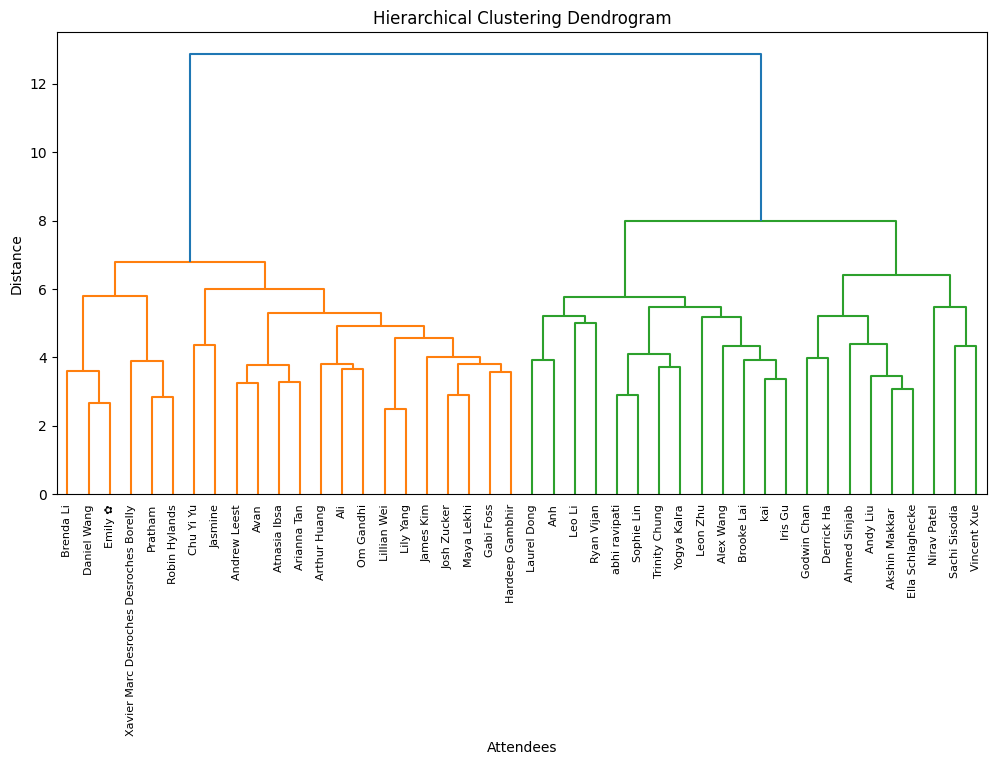

In [337]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

### ======= STEP 1: Perform Agglomerative Clustering ======= ###
# Convert similarity matrix to a distance matrix (Agglomerative Clustering uses distances)
distance_matrix = 1 - affinity_matrix

# Perform Agglomerative Clustering
agglomerative_clusterer = AgglomerativeClustering(
    n_clusters=None,  # If None, uses distance threshold to find clusters
    distance_threshold=0.5,  # Adjust to control cluster granularity (lower = more clusters)
    metric="precomputed",  # Using precomputed affinity (cosine similarity transformed to distance)
    linkage="average"  # 'average' or 'complete' work well with cosine distance
)

labels = agglomerative_clusterer.fit_predict(distance_matrix)

# Store cluster assignments
attendee_cluster_assignments = {name: cluster for name, cluster in zip(attendee_names, labels)}

print(f"✅ Clustering complete! {len(set(labels))} clusters found.")

### ======= STEP 2: Save Cluster Assignments to CSV ======= ###
csv_output_file = "attendee_agglomerative_clusters.csv"

df_clusters = pd.DataFrame({
    "Attendee Name": attendee_names,
    "Cluster ID": labels
})

df_clusters.to_csv(csv_output_file, index=False)
print(f"📂 Cluster labels saved to {csv_output_file}!")

### ======= STEP 3: Dendrogram Visualization ======= ###
def plot_dendrogram(distance_matrix, attendee_names):
    """Plots a hierarchical clustering dendrogram for better cluster visualization."""
    linkage_matrix = linkage(distance_matrix, method="average")  # 'average' for cosine distance

    plt.figure(figsize=(12, 6))
    dendrogram(linkage_matrix, labels=attendee_names, leaf_rotation=90, leaf_font_size=8)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Attendees")
    plt.ylabel("Distance")
    plt.show()

# Plot Dendrogram
plot_dendrogram(distance_matrix, attendee_names)

In [324]:
### ======= STEP 4: Construct k-NN Graph for Spectral Clustering ======= ###
def construct_knn_affinity_matrix(affinity_matrix, k):
    knn_affinity = np.zeros_like(affinity_matrix)

    for i in range(len(affinity_matrix)):
        nearest_indices = np.argsort(affinity_matrix[i])[-(k+1):-1]  # Get k nearest neighbors
        knn_affinity[i, nearest_indices] = affinity_matrix[i, nearest_indices]

    return (knn_affinity + knn_affinity.T) / 2  # Ensure symmetry

knn_affinity_matrix = construct_knn_affinity_matrix(affinity_matrix, K_NEIGHBORS)
print("Constructed k-NN affinity matrix.")

### ======= STEP 5: Perform Spectral Clustering ======= ###
spectral = SpectralClustering(n_clusters=NUM_CLUSTERS, affinity="precomputed", random_state=42)
labels = spectral.fit_predict(knn_affinity_matrix)

print(f"Clustering completed. Found {NUM_CLUSTERS} clusters.")

Constructed k-NN affinity matrix.
Clustering completed. Found 2 clusters.


In [325]:
# Step 6: Store cluster assignments in JSON
cluster_assignments = {name: int(labels[i]) for i, name in enumerate(attendee_names)}
with open("clusters.json", "w") as f:
    json.dump(cluster_assignments, f, indent=4)

print("✅ Cluster assignments saved to clusters.json.")

✅ Cluster assignments saved to clusters.json.


In [326]:
### ======= STEP 7: Save Cluster Labels to CSV ======= ###
with open(CSV_OUTPUT_FILE, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Attendee Name", "Cluster ID"])
    for i, name in enumerate(attendee_names):
        writer.writerow([name, labels[i]])

print(f"Cluster labels successfully saved to {CSV_OUTPUT_FILE}!")

Cluster labels successfully saved to attendee_clusters.csv!


### Visualize

Generating UMAP visualization...


/home/robin/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/robin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


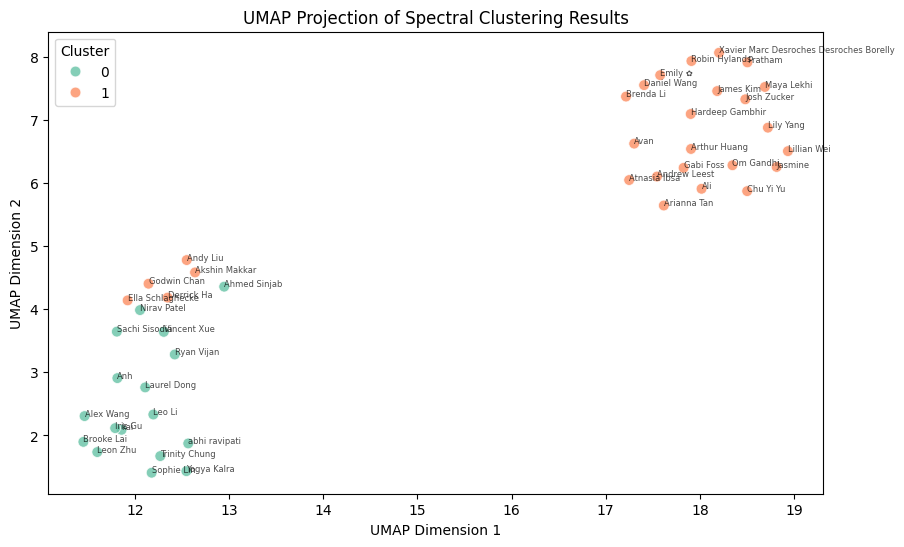

In [327]:
import umap.umap_ as umap
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### ======= STEP 8: UMAP 2D Visualization ======= ###
def visualize_umap_clusters(affinity_matrix, labels, attendee_names):
    """Plots clusters using UMAP for dimensionality reduction."""
    umap_2d = umap.UMAP(n_components=2, random_state=42)
    embedding_2d = umap_2d.fit_transform(affinity_matrix)

    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette="Set2", s=60, alpha=0.8)

    # Annotate points with attendee names
    for i, name in enumerate(attendee_names):
        plt.text(embedding_2d[i, 0], embedding_2d[i, 1], name, fontsize=6, alpha=0.7)

    plt.title("UMAP Projection of Spectral Clustering Results")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.legend(title="Cluster")
    plt.show()

print("Generating UMAP visualization...")
visualize_umap_clusters(affinity_matrix, labels, attendee_names)

Generating graph visualization...


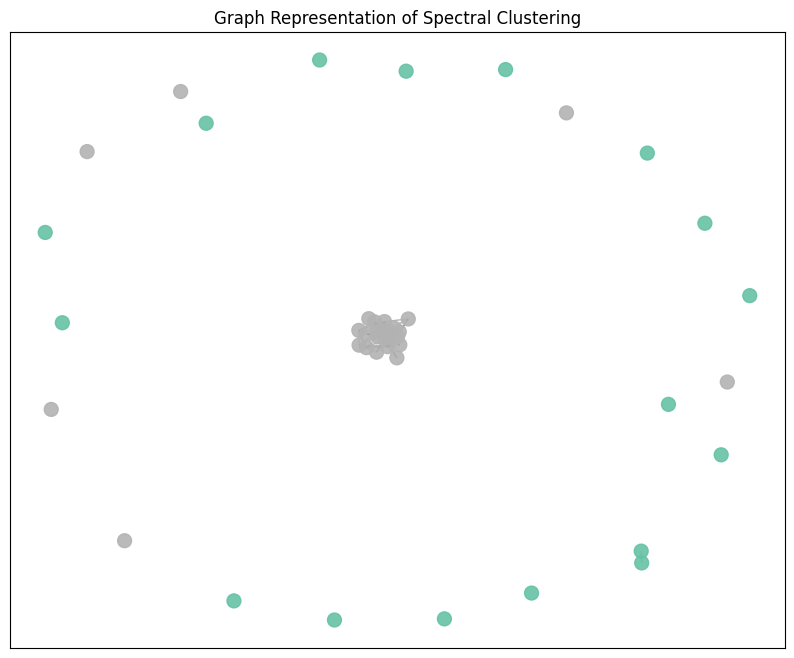

In [328]:
### ======= STEP 9: Network Graph Visualization ======= ###
def visualize_graph(affinity_matrix, labels):
    """Creates a graph visualization where nodes are attendees and edges represent strong similarities."""
    G = nx.Graph()

    # Add nodes with cluster labels
    for i in range(len(labels)):
        G.add_node(i, cluster=labels[i])

    # Add edges based on similarity (only strong connections)
    threshold = np.percentile(affinity_matrix, 90)  # Keep strongest 10% of connections
    for i in range(len(affinity_matrix)):
        for j in range(i + 1, len(affinity_matrix)):  # Avoid duplicate edges
            if affinity_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=affinity_matrix[i, j])

    # Visualize graph
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42)  # Force-directed layout
    node_colors = [labels[i] for i in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2, node_size=100, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.title("Graph Representation of Spectral Clustering")
    plt.show()

print("Generating graph visualization...")
visualize_graph(affinity_matrix, labels)

Generating cluster distribution plot...


/tmp/ipykernel_7532/2744433363.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


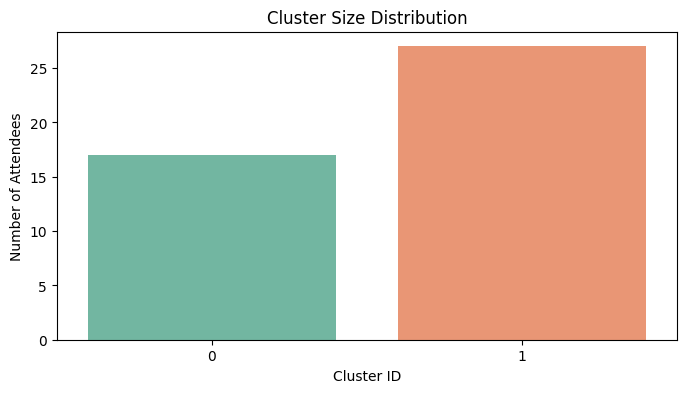

In [329]:
### ======= STEP 10: Cluster Size Distribution ======= ###
def plot_cluster_distribution(labels):
    """Plots the distribution of cluster sizes as a bar chart."""
    df_clusters = pd.DataFrame({"Cluster": labels})
    cluster_counts = df_clusters["Cluster"].value_counts().sort_index()

    plt.figure(figsize=(8, 4))
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Attendees")
    plt.title("Cluster Size Distribution")
    plt.show()

print("Generating cluster distribution plot...")
plot_cluster_distribution(labels)

In [330]:

### ======= STEP 11: Extract Top 3 Matches Per Attendee ======= ###
def get_top_matches(affinity_matrix, attendee_names, labels, top_n=3):
    """Finds the top N highest similarity matches for each attendee."""
    matches_dict = {}

    for i, name in enumerate(attendee_names):
        # Get similarity scores and sort by highest similarity (excluding self)
        similarity_scores = [(attendee_names[j], labels[j], affinity_matrix[i, j]) for j in range(len(attendee_names)) if i != j]
        top_matches = sorted(similarity_scores, key=lambda x: x[2], reverse=True)[:top_n]  # Top N matches
        
        # Store results in dictionary
        matches_dict[name] = {
            "cluster": int(labels[i]),
            "top_matches": [{"name": match[0], "cluster": int(match[1]), "similarity": match[2]} for match in top_matches]
        }

    return matches_dict

# Generate match results
matches = get_top_matches(affinity_matrix, attendee_names, labels, top_n=3)

### ======= STEP 12: Save Matches to JSON File ======= ###
JSON_OUTPUT_FILE = "attendee_top_matches.json"

with open(JSON_OUTPUT_FILE, "w") as json_file:
    json.dump(matches, json_file, indent=4)

print(f"Top 3 matches for each attendee saved to {JSON_OUTPUT_FILE}!")


Top 3 matches for each attendee saved to attendee_top_matches.json!


In [331]:
### ======= Load and Display First 10 Attendees from JSON ======= ###

# Load the JSON file
JSON_OUTPUT_FILE = "attendee_top_matches.json"

with open(JSON_OUTPUT_FILE, "r") as json_file:
    matches_data = json.load(json_file)

n_display = 50
# Get the first 10 attendees
first_n_attendees = list(matches_data.items())[:n_display]

# Print them nicely formatted
for attendee, data in first_n_attendees:
    print(f"\n👤 Attendee: {attendee} (Cluster {data['cluster']})")
    print("   🔝 Top Matches:")
    for match in data["top_matches"]:
        print(f"   - {match['name']} (Cluster {match['cluster']}, Similarity: {match['similarity']:.2f})")



👤 Attendee: Ahmed Sinjab (Cluster 0)
   🔝 Top Matches:
   - Arianna Tan (Cluster 1, Similarity: 0.92)
   - Chu Yi Yu (Cluster 1, Similarity: 0.88)
   - Josh Zucker (Cluster 1, Similarity: 0.86)

👤 Attendee: Atnasia Ibsa (Cluster 1)
   🔝 Top Matches:
   - Arianna Tan (Cluster 1, Similarity: 2.41)
   - Hardeep Gambhir (Cluster 1, Similarity: 2.15)
   - Robin Hylands (Cluster 1, Similarity: 2.06)

👤 Attendee: Akshin Makkar  (Cluster 1)
   🔝 Top Matches:
   - Leon Zhu (Cluster 0, Similarity: 0.82)
   - Godwin Chan (Cluster 1, Similarity: 0.72)
   - Lillian Wei (Cluster 1, Similarity: 0.66)

👤 Attendee: Alex Wang (Cluster 0)
   🔝 Top Matches:
   - Sophie Lin (Cluster 0, Similarity: 1.21)
   - Iris Gu (Cluster 0, Similarity: 1.14)
   - abhi ravipati (Cluster 0, Similarity: 1.11)

👤 Attendee: Andy Liu (Cluster 1)
   🔝 Top Matches:
   - Brenda Li (Cluster 1, Similarity: 0.80)
   - Emily ✿ (Cluster 1, Similarity: 0.74)
   - Xavier Marc Desroches Desroches Borelly (Cluster 1, Similarity: 0.70)
